In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [ ]:
# plotting settings
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec
from importlib import reload

In [7]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import summary

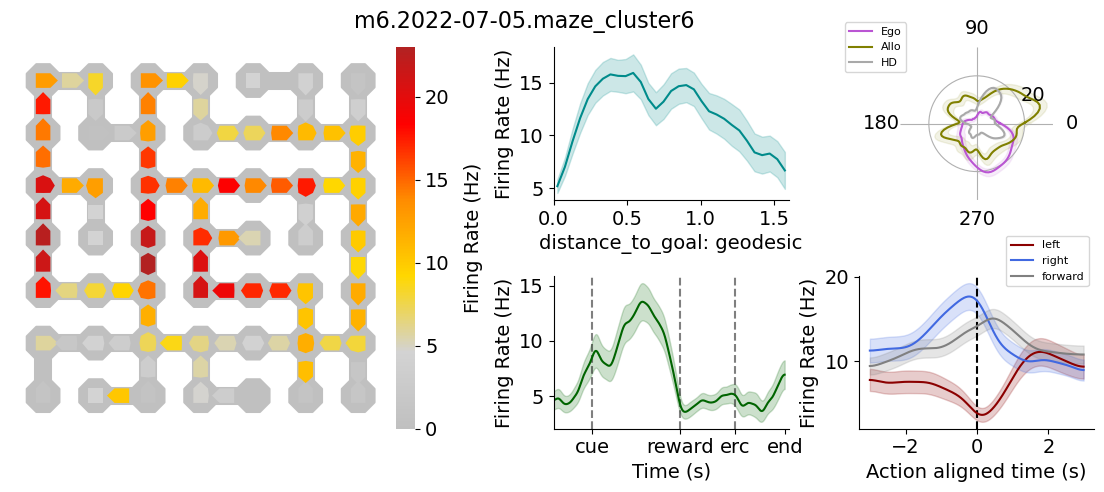

In [12]:
reload(summary)
Cluster = gc.get_cluster("m6.2022-07-05.maze_cluster6")
fig = summary.plot_tuning_summary_concise(Cluster)
fig.savefig("../results/nbeGLM/figures/cluster_tuning_summary.pdf")

In [3]:
from GridMaze.analysis.nbeGLM import load_model_sets as lms
from GridMaze.analysis.nbeGLM import model_comparisons as mc

# model performance validation

baseline vs embedding:
                                       feature_group model_type     t_stat  \
0                                    place_direction  baseline2  12.653782   
1                                    place_direction   baseline  11.352804   
2                   place_direction_distance_to_goal  baseline2  14.124332   
3                   place_direction_distance_to_goal   baseline  12.654865   
4  place_direction_distance_to_goal_egocentric_ac...  baseline2  14.647176   
5  place_direction_distance_to_goal_egocentric_ac...   baseline  13.339330   
6                                              place   baseline   7.149507   

      p_val  p_val_corr  
0  0.000055    0.000077  
1  0.000093    0.000108  
2  0.000032    0.000077  
3  0.000055    0.000077  
4  0.000027    0.000077  
5  0.000042    0.000077  
6  0.000832    0.000832  


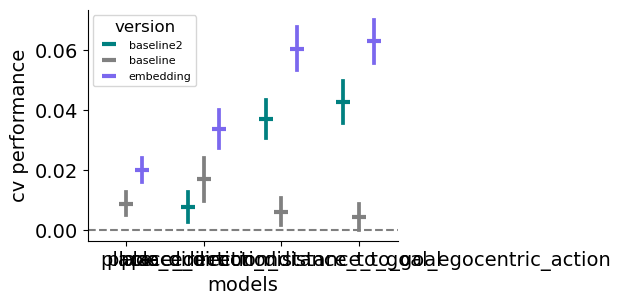

In [4]:
nbe_validation = lms.load_model_set_cv_scores(
    model_set="performance_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=False
)
f, ax = plt.subplots(figsize=(4, 3))
mc.plot_performance_validation(nbe_validation, ax=ax)
f.savefig("../results/nbeGLM/figures/performance_validation.pdf")

# feature-group interactions validation

In [6]:
interaction_validation_results = lms.load_model_set_cv_scores(
    "interaction_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)

place_direction_linear vs place_direction_nonlinear
t_stat: -4.024459885238532, p_val: 0.010076231225571018
place_direction_distance_to_goal_linear vs place_direction_distance_to_goal_nonlinear
t_stat: 2.881913045778083, p_val: 0.03451091861071185


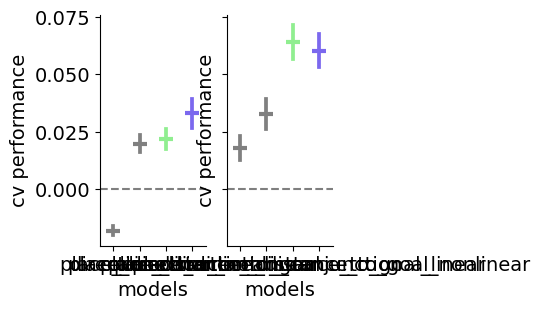

In [7]:
reload(mc)
f, axes = plt.subplots(1, 2, figsize=(3, 3), sharey=True)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=["place", "direction", "place_direction_linear", "place_direction_nonlinear"],
    ax=axes[0],
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=[
        "place_direction_conjunction",
        "distance_to_goal",
        "place_direction_distance_to_goal_linear",
        "place_direction_distance_to_goal_nonlinear",
    ],
    ax=axes[1],
)

# unique variance explained

In [8]:
from GridMaze.analysis.nbeGLM import variance_explained as ve

In [80]:
variance_explained_results = lms.load_model_set_cv_scores(
    "variance_explained", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
cpd_df = ve.get_cpd_df(variance_explained_results, outlier_threshold=-0.2)
feature_tuned_df = ve.get_feature_tuned_df(variance_explained_results)
compare_features = ["distance_to_goal", "place_direction", "egocentric_action_action"]

                    feature    t_stat     p_val  p_val_corr
0          distance_to_goal  4.410531  0.003477    0.004790
1  egocentric_action_action  4.075620  0.004790    0.004790
2           place_direction  5.403597  0.001467    0.004401


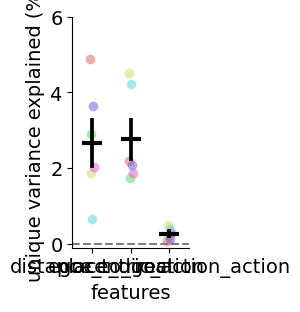

In [81]:
reload(ve)
f, ax = plt.subplots(figsize=(1.5, 3))
ve.plot_variance_explained(cpd_df, features=compare_features, plot_single_subject=True, print_stats=True, ax=ax)
ax.set_ylim(-0.1, 6)
f.savefig("../results/nbeGLM/figures/unique_variance_explained.pdf")

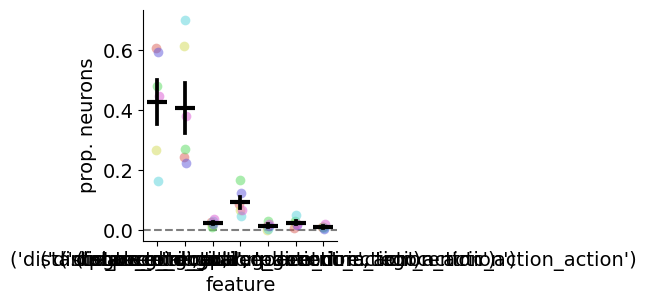

In [82]:
reload(ve)
f, ax = plt.subplots(figsize=(2.5, 3))
ve.plot_summary_pointplot(
    feature_tuned_df,
    models=compare_features,
    ax=ax,
)
f.savefig("../results/nbeGLM/figures/feature_tuning_summary.pdf")

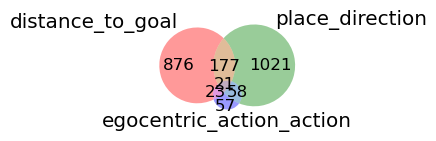

In [83]:
reload(ve)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ve.plot_summary_venn_diagram(
    feature_tuned_df,
    models=compare_features,
    ax=ax,
)
fig.savefig("../results/nbeGLM/figures/feature_tuning_venn.pdf")

unique variance explained with more input features

In [79]:
variance_explained_full_results = lms.load_model_set_cv_scores(
    "variance_explained_full",
    maze_names=[
        "maze_1",
        "maze_2",
        "rooms_maze",
    ],
    all_completed=False,
)
reduced_models = [
    "remove_place_direction",
    "remove_distance_to_goal",
    "remove_egocentric_action_free_forced",
    "remove_egocentric_action_action",
    "remove_goal",
    "remove_allocentric_angle_to_goal",
    "remove_egocentric_angle_to_goal",
    "remove_head_direction",
    "remove_speed",
    "remove_acceleration",
]
cpd_full_df = ve.get_cpd_df(variance_explained_full_results, reduced_models=reduced_models, outlier_threshold=-0.2)

                         feature    t_stat     p_val  p_val_corr
0                   acceleration  1.720792  0.072956    0.145913
1      allocentric_angle_to_goal -0.470583  0.671124    0.838905
2               distance_to_goal  5.650349  0.001206    0.003014
3       egocentric_action_action  1.146919  0.151659    0.252765
4  egocentric_action_free_forced  0.926011  0.198468    0.283526
5       egocentric_angle_to_goal -1.278543  0.871407    0.968229
6                           goal -5.106433  0.998125    0.998125
7                 head_direction  9.250198  0.000124    0.001241
8                place_direction  5.755519  0.001111    0.003014
9                          speed  6.301882  0.000740    0.003014


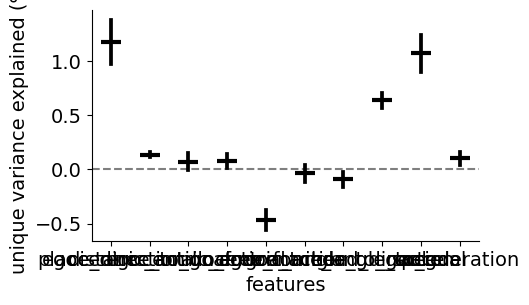

In [78]:
reload(ve)
f, ax = plt.subplots(figsize=(5, 3))
ve.plot_variance_explained(cpd_full_df, features=[f.split("_", 1)[-1] for f in reduced_models], print_stats=True, ax=ax)

# main feature interactions 

In [74]:
main_feature_interactions = lms.load_model_set_cv_scores(
    "main_feature_interactions",
    maze_names=["maze_1", "maze_2", "rooms_maze"],
    all_completed=True,
)

                                             model_1  \
0  place-direction-distance_to_goal-egocentric_ac...   
1  place-direction-distance_to_goal-egocentric_ac...   
2  place.direction-distance_to_goal-egocentric_ac...   

                                             model_2    t_stat     p_val  \
0  place.direction-distance_to_goal-egocentric_ac... -3.249279  0.022714   
1  place.direction.distance_to_goal.egocentric_ac... -3.119532  0.026266   
2  place.direction.distance_to_goal.egocentric_ac...  2.222501  0.076886   

   p_val_corr  
0    0.039399  
1    0.039399  
2    0.076886  


(0.04, 0.08)

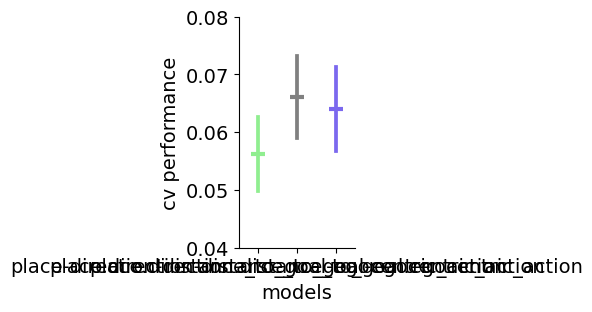

In [76]:
reload(mc)
f, ax = plt.subplots(figsize=(1.5, 3))
mc.plot_main_feature_interactions(main_feature_interactions, plot_single_subjects=False, outlier_threshold=-0.2, ax=ax)
ax.set_ylim(0.04, 0.08)

# visualising embedding latent tuning